# TASK 1: Date Feature Engineering

In [5]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv('/content/data/q3_retail_promotions.csv')

# View data
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [8]:
# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

In [9]:
# Create is_month_end (1 if day >= 25 else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

In [10]:
# Check new columns
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

- Extracted year, month, and day_of_week from transaction_date.
- Created a new feature is_month_end to capture end-of-month purchasing behavior.
- These features help capture temporal patterns in sales data.

# TASK 2: Temporal Train-Test Split (NO RANDOM SPLIT)

In [11]:
# Sort data by date
df = df.sort_values(by='transaction_date')

# Define split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split data
train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Separate features and target
X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']

X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

# Check shapes
X_train.shape, X_test.shape

((960, 12), (240, 12))

### Temporal Train-Test Split

- The dataset was sorted based on transaction_date.
- The first 80% of records were used for training, and the most recent 20% were used for testing.
- A random split is not appropriate for time-series data because it can cause data leakage.
- Using past data to predict future values ensures a realistic evaluation of model performance.

# TASK 3: Pipeline (ColumnTransformer + Models)

In [12]:
# Import required libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['store_id', 'competition_density', 'year', 'month',
                  'day_of_week', 'is_month_end', 'is_weekend', 'is_festival']

# Create transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

# Create pipeline (only preprocessing for now)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit on training data ONLY
pipeline.fit(X_train)

# Transform both train and test
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Check shape
X_train_processed.shape, X_test_processed.shape

((960, 16), (240, 16))

### Preprocessing Pipeline

- A preprocessing pipeline was created using ColumnTransformer.
- Numerical features were scaled using StandardScaler.
- Categorical features were converted into numerical format using One-Hot Encoding.
- The pipeline was fit only on the training data to prevent data leakage.
- The same transformation was applied to both training and testing sets.

# TASK 4: Model Training

In [13]:
# Import models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# -------- Linear Regression --------
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

# -------- Random Forest --------
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

# -------- Evaluation --------
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{model_name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
RMSE: 27.121451164890626
MAE: 21.05292667458839

Random Forest
RMSE: 31.656644582930767
MAE: 24.864791666666665


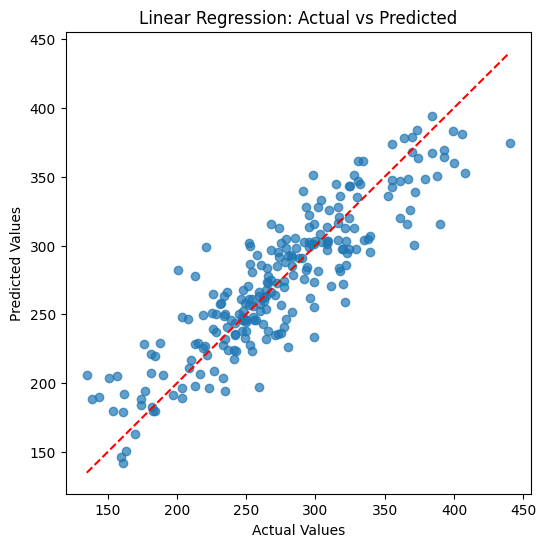

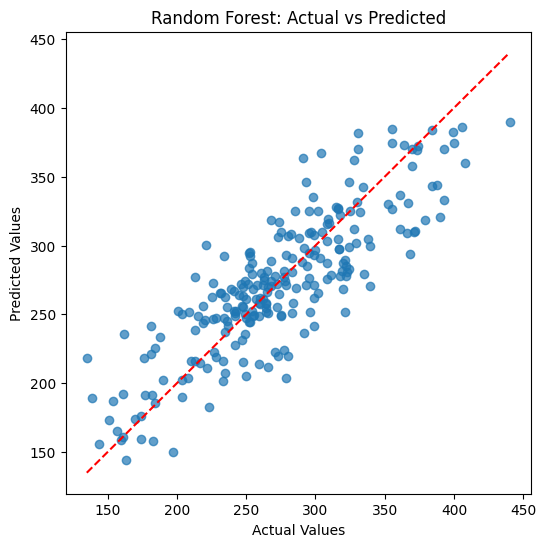

In [14]:
import matplotlib.pyplot as plt

# -------- Linear Regression Plot --------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()


# -------- Random Forest Plot --------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

### Parity Plot (Actual vs Predicted)

- The parity plots compare predicted values with actual values.
- The red diagonal line represents perfect predictions.
- Points closer to the diagonal line indicate better model performance.
- Linear Regression shows predictions closer to the line compared to Random Forest.
- This confirms that Linear Regression performs better on this dataset.

### Model Evaluation

- Both Linear Regression and Random Forest models were evaluated using RMSE and MAE.
- Linear Regression achieved lower RMSE (~27.12) and MAE (~21.05) compared to Random Forest.
- Random Forest showed higher error, possibly due to lack of hyperparameter tuning or the dataset having mostly linear relationships.

### Best Model Selection

- Linear Regression performed better based on both RMSE and MAE.
- It provides more accurate predictions on this dataset.
- Therefore, Linear Regression is selected as the best model for this task.

In [15]:
# Get feature importance from Random Forest
import pandas as pd

feature_importance = rf.feature_importances_

# Get feature names from pipeline
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort and get top 5
importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(5)

,Feature,Importance
15,cat__store_size_small,0.183970
7,num__is_festival,0.174478
13,cat__location_type_urban,0.140503
4,num__day_of_week,0.088301
6,num__is_weekend,0.065733


### Feature Importance

- Feature importance was extracted from the Random Forest model.
- It indicates how much each feature contributes to predicting items_sold.
- The top 5 most important features are:
  - store_size_small
  - is_festival
  - location_type_urban
  - day_of_week
  - is_weekend
- These results suggest that store characteristics, festival periods, and timing (weekday/weekend) play a key role in influencing sales.
- Understanding these features helps in identifying key drivers of customer purchasing behavior.